# 01. Sun and shadows

Where is the sun over Melbourne, hour by hour, and what does the city block?

Two things happen here. First `pvlib` gives an azimuth and an elevation for every hour of
one day. Then the DSM from 00 gets marched along that bearing: a cell is in shade if
anything upwind of it is tall enough to clear the beam. Out comes one boolean raster per
hour, `shade_06` through `shade_20`, which every notebook downstream leans on.

In [ ]:
import json
import numpy as np
import matplotlib.pyplot as plt

CONFIG = json.load(open("config.json"))

W, H  = CONFIG["grid"]["width"], CONFIG["grid"]["height"]
MINX, MINY = CONFIG["grid"]["minx"], CONFIG["grid"]["miny"]
MAXX, MAXY = CONFIG["grid"]["maxx"], CONFIG["grid"]["maxy"]
LAT, LON = CONFIG["lat"], CONFIG["lon"]

In [ ]:
dsm = np.load("out/rasters/dsm_buildings.npy")
canopy = np.load("out/rasters/dsm_canopy.npy")

# merge dsm and canopy using tallest value at each pixel
surface = np.maximum(dsm, canopy)

## PVLIB: Finding where the sun is

In [29]:
import pandas as pd
from pvlib.solarposition import get_solarposition
DATE = "2026-01-15"       # a sample summer day
TZ   = "Australia/Melbourne"
HOURS = range(6, 21)

times = pd.to_datetime([f"{DATE} {hr:02d}:00" for hr in HOURS]).tz_localize(TZ)
sun = get_solarposition(times, LAT, LON)[["azimuth", "apparent_elevation"]]

# Print the sun's position for each hour az=azimuth, el=elevation
for t, row in sun.iterrows():
    print(f"{t:%H:%M}  az {row.azimuth:6.1f}deg   el {row.apparent_elevation:6.1f}deg")

06:00  az  120.2deg   el   -3.3deg
07:00  az  111.2deg   el    7.5deg
08:00  az  102.8deg   el   18.7deg
09:00  az   94.3deg   el   30.4deg
10:00  az   85.0deg   el   42.2deg
11:00  az   73.3deg   el   53.8deg
12:00  az   55.5deg   el   64.5deg
13:00  az   22.9deg   el   72.2deg
14:00  az  336.2deg   el   72.1deg
15:00  az  304.1deg   el   64.3deg
16:00  az  286.4deg   el   53.6deg
17:00  az  274.8deg   el   41.9deg
18:00  az  265.6deg   el   30.1deg
19:00  az  257.2deg   el   18.4deg
20:00  az  248.7deg   el    7.2deg


In [31]:
# Write the date to config so other notebooks can use it
CONFIG["date"] = DATE
json.dump(CONFIG, open("config.json", "w"), indent=4)

## Calculate Shadows

In [ ]:
h_bldg = 100.0    # a sample 100m building height

for hr in (7, 13, 17):
    el = sun.loc[sun.index.hour == hr, "apparent_elevation"].item()
    az = sun.loc[sun.index.hour == hr, "azimuth"].item()
    length = h_bldg / np.tan(np.radians(el))
    print(f"{hr:02d}:00  el {el:4.1f}deg  az {az:5.1f}deg  ->  shadow {length:6.0f} m")

07:00  el  7.5deg  az 111.2deg  ->  shadow    765 m
13:00  el 72.2deg  az  22.9deg  ->  shadow     32 m
17:00  el 41.9deg  az 274.8deg  ->  shadow    111 m


In [40]:
EL = 20.0  # sample elevation of the sun in degrees
# Use the tangent of elevation to calculate how much shadow is cast
t  = np.tan(np.radians(EL))


**How a cell `i` determines if its shaded (1D)**:
```

                                                                                         ☀ (Sun, 20° up)
                        10m                                                        _ . - '
                        ████                                  4m            _ . - '
                        ████                               ▒▒▒▒▒▒▒  _ . - '
                        ████                               ▒▒    ▒
  #    #     #     #      .      #     #     #     #     #     .
  0    1     2     3      4      5     6     7     8     9     10
  <-- tower's shadow      <-- shop's shadow
  ```
 >Assume sun is to the right each cell walks right and checks whether its sightline is blocked or
 >not if blocked it is shaded if not its sunlit

In [42]:
row = np.zeros(16)
row[4]  = 10.0    # a tower
row[10] = 4.0     # a low shopfront
CELL = CONFIG["cell_size"]  # cell size in metres

# For each cell check if it is shaded by any
shaded = np.zeros(16, bool)
for i in range(16):
    for j in range(i + 1, 16):                          # every cell between i and the sun
        beam = (j - i) * CELL * t        # how high the beam is above ground at j
        if row[j] > beam:                               # if j is taller than beam, i is shaded
            shaded[i] = True
            break

print("height ", "".join(f"{v:>3.0f}" for v in row))
print("shade  ", "".join(f"{'#' if s else '.':>3}" for s in shaded))

print("\n #: shaded, .: sunlit")

height    0  0  0  0 10  0  0  0  0  0  4  0  0  0  0  0
shade     #  #  #  #  .  #  #  #  #  #  .  .  .  .  .  .

 #: shaded, .: sunlit


In [45]:
# Same as above but numpy does the work making it much faster

t = np.tan(np.radians(EL))

blocked = np.zeros(16, bool)
for d in range(1, 16):
    lifted = np.zeros(16)
    lifted[:-d] = row[d:] - d * CELL * t     # cell i sees cell i+d, minus the beam height there
    blocked |= lifted > 0

print("shade  ", "".join(f"{'#' if s else '.':>3}" for s in blocked))

shade     #  #  #  #  .  #  #  #  #  #  .  .  .  .  .  .


## From a row to a bearing

The row only worked because the sun sat at one end of it. In 2-D the beam arrives on a
compass bearing, so "the cell `d` away toward the sun" has to be resolved into a row and a
column offset.

Azimuth is degrees clockwise from north. Stepping `k` cells toward the sun:

```
dc = +k * sin(az)      east is +col
dr = -k * cos(az)      north is -row  (row 0 is the north edge)
```

At az = 0 (sun due north, near noon here) that's `dr = -k`, straight up the array, and
shadows fall southward down it. At az = 90 (due east) it's `dc = +k`. The minus on `dr` is
the raster convention from 00 leaking in, and getting it backwards flips every shadow in
the city 180 degrees — which at least is obvious in the figure.

In [47]:
def beam_offsets(az, el, max_h):
    """Integer (dr, dc, distance_m) steps from a cell toward the sun, nearest first."""
    a = np.radians(az)
    reach = max_h / np.tan(np.radians(el))            # longest shadow anything can cast
    k_max = min(reach / CELL, 800)                    # cells; capped so dawn stays tractable

    seen, offs = set(), []
    for k in np.arange(0.25, k_max, 0.25):            # quarter-cell steps, no gaps in the line
        dr, dc = int(round(-k * np.cos(a))), int(round(k * np.sin(a)))
        if (dr, dc) in seen or (dr, dc) == (0, 0):
            continue
        seen.add((dr, dc))
        offs.append((dr, dc, k * CELL))               # first time seen = shortest true distance
    return offs

In [49]:
az9  = sun.loc[sun.index.hour == 9,  "azimuth"].item()
el9  = sun.loc[sun.index.hour == 9,  "apparent_elevation"].item()
o = beam_offsets(az9, el9, surface.max())
print(f"09:00  az {az9:.1f}deg el {el9:.1f}deg  ->  {len(o)} steps, out to {o[-1][2]:.0f} m")
print("first five:", [(dr, dc) for dr, dc, _ in o[:5]])

09:00  az 94.3deg el 30.4deg  ->  266 steps, out to 506 m
first five: [(0, 1), (0, 2), (0, 3), (0, 4), (0, 5)]


## The "March"

In [50]:
def shade_at(surface, az, el):
    """True where the direct beam is blocked."""
    H, W = surface.shape
    if el <= 0:
        return np.ones((H, W), bool)                  # sun's down, all of it is shade

    t = np.tan(np.radians(el))
    blocked = np.zeros((H, W), bool)

    for dr, dc, dist in beam_offsets(az, el, surface.max()):
        lifted = np.zeros((H, W), np.float32)
        rs = slice(max(dr, 0), H - max(-dr, 0))       # source rows
        cs = slice(max(dc, 0), W - max(-dc, 0))
        rd = slice(max(-dr, 0), H - max(dr, 0))       # destination rows
        cd = slice(max(-dc, 0), W - max(dc, 0))
        lifted[rd, cd] = surface[rs, cs] - dist * t
        blocked |= lifted > 0

    return blocked

## Plotting it out

In [62]:
from matplotlib.colors import ListedColormap

VIEW_M = 3000
half = int(VIEW_M / CELL / 2)
VIEW = np.s_[H // 2 - half : H // 2 + half,
             W // 2 - half : W // 2 + half]

base = surface[VIEW]
SHADE_COLOR = ListedColormap(["#12306b"])

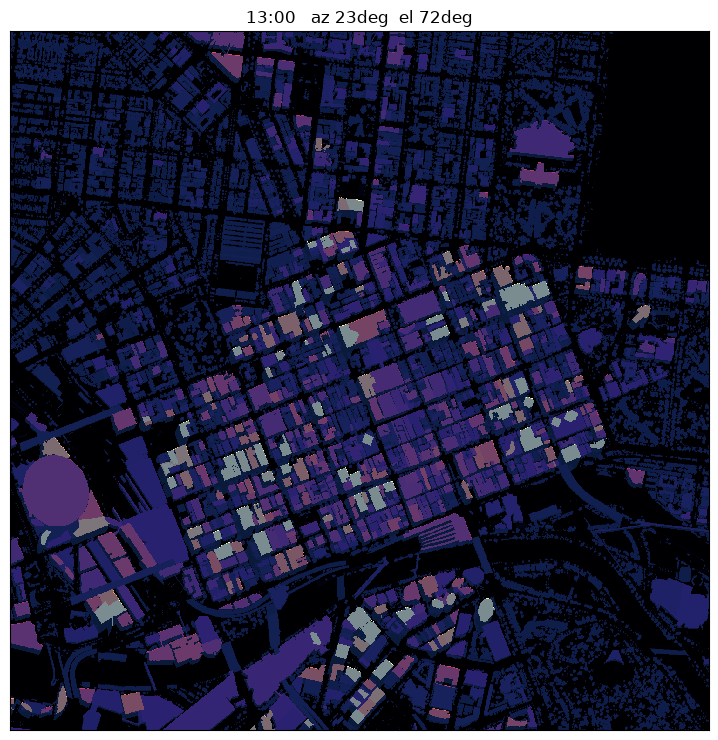

In [64]:
def draw_shade(ax, sh, title=""):
    """Shade mask (already cropped to VIEW) in translucent blue over the DSM."""
    ax.imshow(base, cmap="magma", vmax=120, interpolation="nearest")
    ax.imshow(np.ma.masked_where(~sh, sh), cmap=SHADE_COLOR, alpha=0.55, interpolation="nearest")
    ax.set_title(title)
    ax.set_xticks([]); ax.set_yticks([])

SAMPLE_HOUR = 13
SAMPLE_MINUTE = 0
t13 = sun.index[(sun.index.hour == SAMPLE_HOUR) & (sun.index.minute == SAMPLE_MINUTE)][0]
az, el = sun.loc[t13, "azimuth"], sun.loc[t13, "apparent_elevation"]

fig, ax = plt.subplots(figsize=(8, 7.5))
draw_shade(ax, shade_at(surface, az, el)[VIEW], f"{SAMPLE_HOUR:02d}:{SAMPLE_MINUTE:02d}   az {az:.0f}deg  el {el:.0f}deg")
fig.tight_layout()


### Testing for 9:00-21:00 (30 minute intervals)

In [69]:
times = pd.date_range(f"{DATE} 06:00", f"{DATE} 21:00", freq="30min", tz=TZ)
sun = get_solarposition(times, LAT, LON)[["azimuth", "apparent_elevation"]]

for t, r in sun[sun.index.minute == 0].iterrows():
    print(f"{t:%H:%M}  az {r.azimuth:6.1f}deg   el {r.apparent_elevation:6.1f}deg")

06:00  az  120.2deg   el   -3.3deg
07:00  az  111.2deg   el    7.5deg
08:00  az  102.8deg   el   18.7deg
09:00  az   94.3deg   el   30.4deg
10:00  az   85.0deg   el   42.2deg
11:00  az   73.3deg   el   53.8deg
12:00  az   55.5deg   el   64.5deg
13:00  az   22.9deg   el   72.2deg
14:00  az  336.2deg   el   72.1deg
15:00  az  304.1deg   el   64.3deg
16:00  az  286.4deg   el   53.6deg
17:00  az  274.8deg   el   41.9deg
18:00  az  265.6deg   el   30.1deg
19:00  az  257.2deg   el   18.4deg
20:00  az  248.7deg   el    7.2deg
21:00  az  239.7deg   el   -3.6deg


In [75]:
import os
os.makedirs("out/rasters", exist_ok=True)

frames = {}                                   # "HH:MM" -> (cropped mask, az, el)
for t, r in sun.iterrows():
    out_path = f"out/rasters/shade_{t.hour:02d}.npy"
    if os.path.exists(out_path):
        print(f"{t:%H:%M}  el {el:5.1f}deg  shaded {100 * sh.mean():4.1f}%  (skipping, already exists)")
        continue
    
    az, el = r.azimuth, r.apparent_elevation
    sh = shade_at(surface, az, el)
    frames[f"{t:%H:%M}"] = (sh[VIEW], az, el)

    if t.minute == 0 and 6 <= t.hour <= 20:   # only the hours the rest of the chain marches on
        np.save(out_path, sh)

    print(f"{t:%H:%M}  el {el:5.1f}deg  shaded {100 * sh.mean():4.1f}%")

06:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
06:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
07:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
07:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
08:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
08:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
09:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
09:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
10:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
10:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
11:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
11:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
12:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
12:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
13:00  el  36.3deg  shaded 47.5%  (skipping, already exists)
13:30  el  36.3deg  shaded 47.5%  (skipping, already exists)
14:00  el  36.3deg  shad

In [ ]:
%matplotlib inline
import ipywidgets as widgets

def show_hour(label):
    sh, az, el = frames[label]
    fig, ax = plt.subplots(figsize=(8, 7.5))
    draw_shade(ax, sh, f"{label}   az {az:.0f}deg  el {el:.0f}deg")
    plt.show()

widgets.interact(
    show_hour,
    label=widgets.SelectionSlider(
        options=list(frames), value="13:00", description="time",
        continuous_update=False, layout=widgets.Layout(width="600px"),
    ),
)

interactive(children=(SelectionSlider(continuous_update=False, description='time', index=14, layout=Layout(wid…

<function __main__.show_hour(label)>

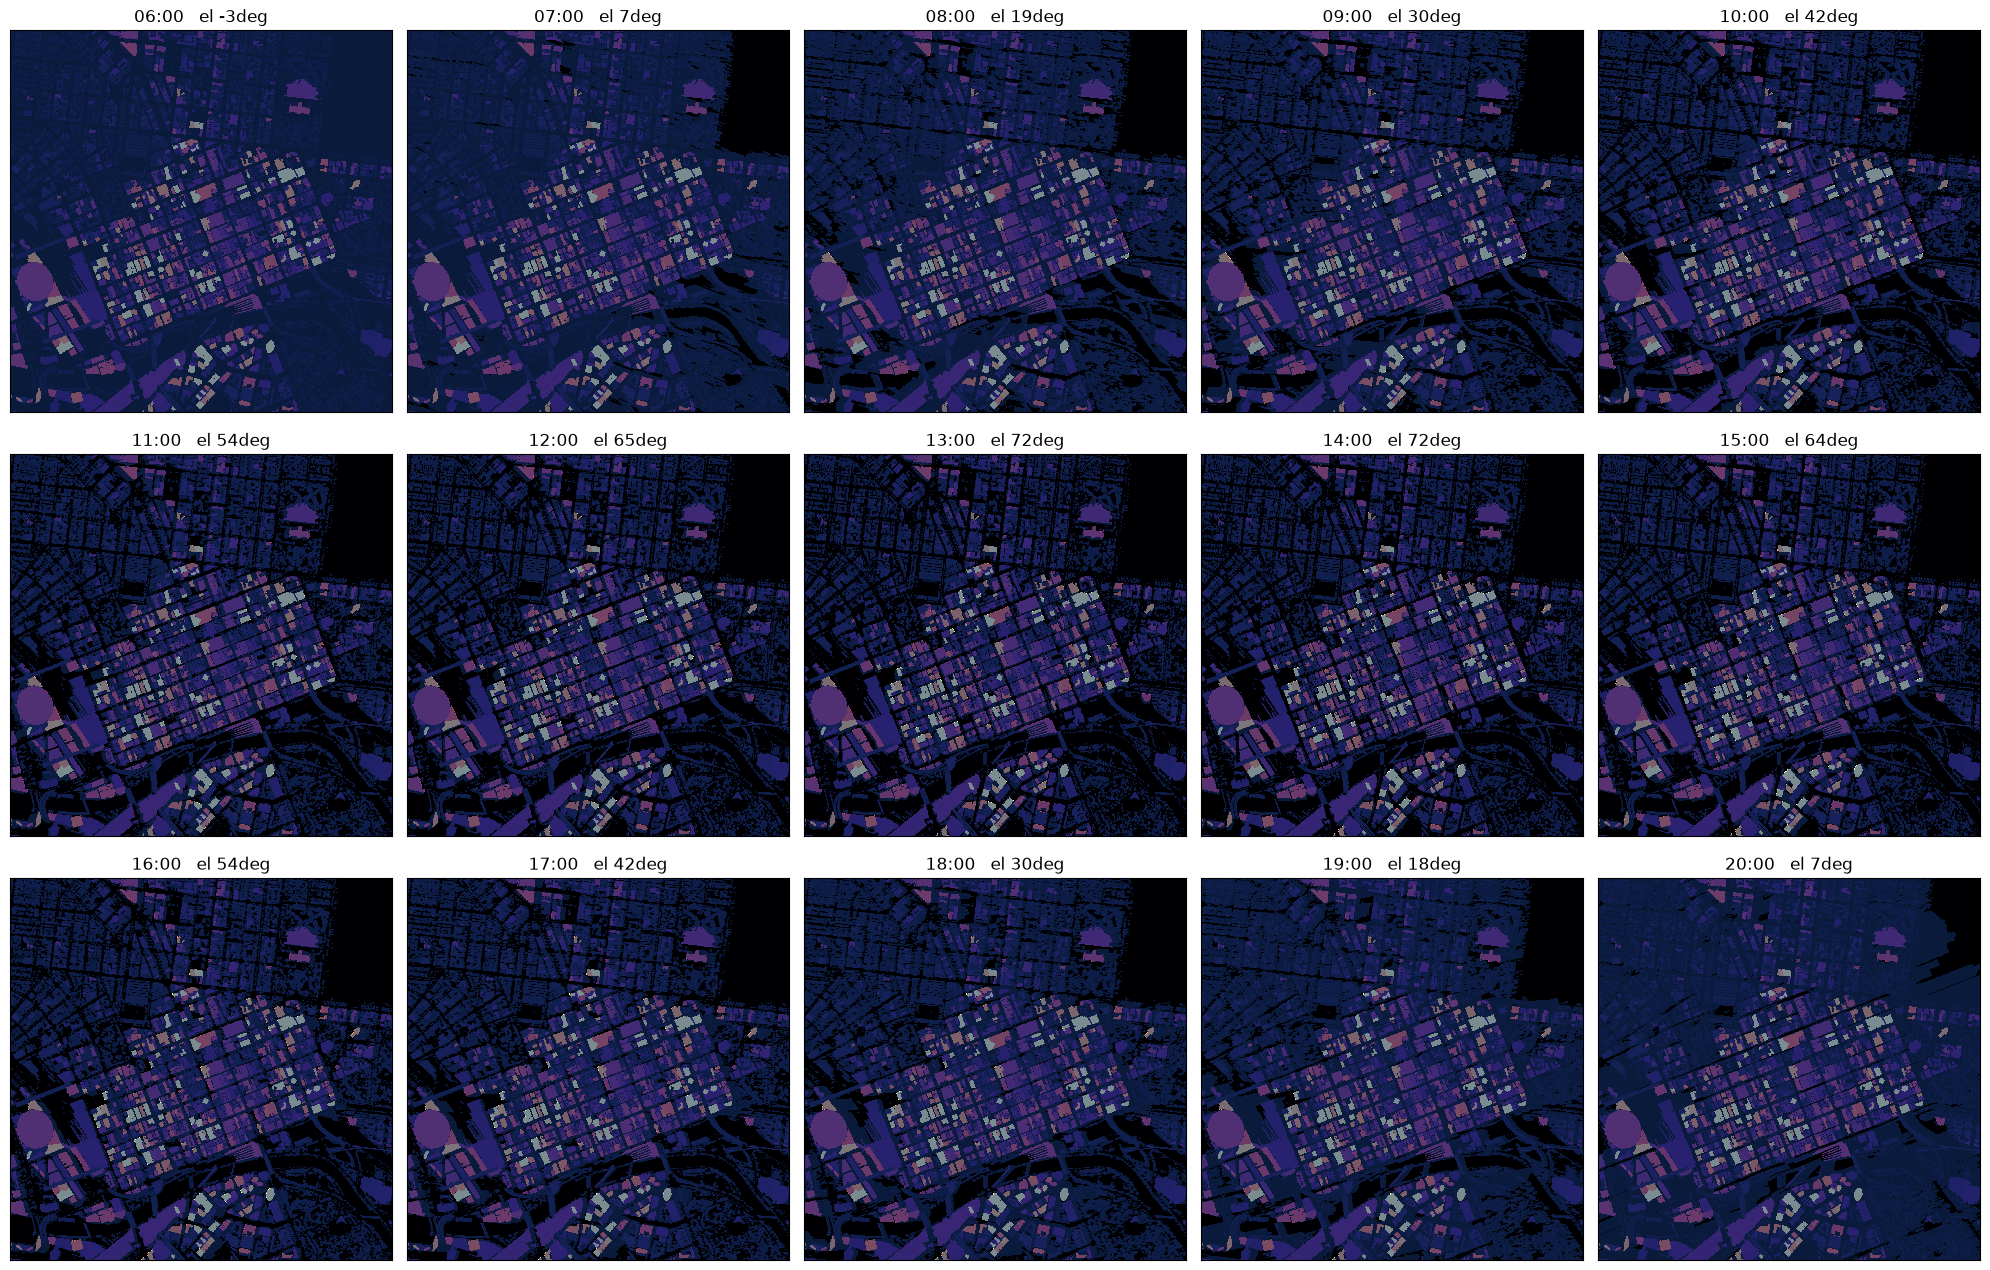

In [71]:
hours = [f"{hr:02d}:00" for hr in range(6, 21)]

fig, axes = plt.subplots(3, 5, figsize=(20, 13))
for ax, label in zip(axes.ravel(), hours):
    sh, az, el = frames[label]
    draw_shade(ax, sh, f"{label}   el {el:.0f}deg")
fig.tight_layout()